In [14]:
!pip install openai pillow -q

In [ ]:
import openai
from google.colab import files
from PIL import Image
import requests
from io import BytesIO
import matplotlib.pyplot as plt

# Setup OpenAI client
client = openai.OpenAI(
    api_key="s..................3A",   # replace with your key
    base_url="http...........lab.com"
)

In [16]:
image_url="https://images.stockcake.com/public/8/e/b/8eb0e591-e021-4469-90ef-9527f3389237/joyful-rainy-play-stockcake.jpg"

(np.float64(-0.5), np.float64(1455.5), np.float64(815.5), np.float64(-0.5))

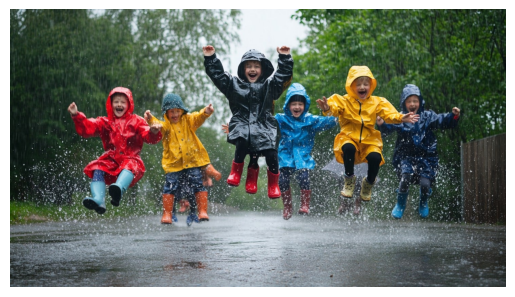

In [17]:

resp = requests.get(image_url)
img = Image.open(BytesIO(resp.content))

plt.imshow(img)
plt.axis("off")


In [18]:
def ask_image_question_url(image_url, question):
    response = client.chat.completions.create(
        model="gemini-2.5-flash",
        messages=[
            {"role": "system", "content": "You are a helpful assistant for Visual Question Answering."},
            {
                "role": "user",
                "content": [
                    {"type": "text", "text": question},
                    {"type": "image_url", "image_url": {"url": image_url}}
                ]
            }
        ],
        temperature=0
    )
    return response.choices[0].message.content

In [19]:
questions = [
    "How many children are visible in the image?",
    "What are the children doing?",
    "What kind of weather is shown in the scene?",
    "What colors of raincoats are the children wearing?",
    "How do the children appear to be feeling?",
    "What time of day does it seem to be?",
    "Describe the overall scene in one clear sentence."
]

for q in questions:
    print("Question:", q)
    print("Answer:", ask_image_question_url(image_url, q))
    print()


Question: How many children are visible in the image?
Answer: There are 6 children visible in the image.

Question: What are the children doing?
Answer: The children are joyfully jumping and splashing in puddles while it's raining. They are all wearing colorful raincoats and rain boots, and they appear to be having a lot of fun.

Question: What kind of weather is shown in the scene?
Answer: The scene shows **rainy** weather.

This is evident from:
*   The children are wearing raincoats and rain boots.
*   There are visible raindrops falling.
*   The ground is wet, and water is splashing as the children jump, indicating puddles.

Question: What colors of raincoats are the children wearing?
Answer: The children are wearing raincoats in the following colors:
*   Red
*   Yellow
*   Black
*   Blue
*   Dark blue

Question: How do the children appear to be feeling?
Answer: The children appear to be feeling **joyful, excited, and incredibly happy**.

Their wide smiles, open mouths (suggesting 